## 14 Αναπαραστάσεις κειμένου με βάση τη συχνότητα

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Μία από τις παλαιότερες και πιο διαδεδομένες προσεγγίσεις βασίζεται σε μια απλή αλλά ισχυρή ιδέα: τη μέτρηση της συχνότητας εμφάνισης των λέξεων. Σύμφωνα με αυτή τη λογική, ένα κείμενο μπορεί να αναπαρασταθεί ως ένα σύνολο λέξεων και κάθε λέξη μπορεί να αντιμετωπιστεί ως χαρακτηριστικό. Η παρουσία ή η συχνότητα των λέξεων σε ένα κείμενο σχηματίζει έτσι ένα διάνυσμα αριθμών που μπορεί να χρησιμοποιηθεί από αλγορίθμους ταξινόμησης, ομαδοποίησης ή αναζήτησης.

Η προσέγγιση αυτή βασίζεται σε μια θεμελιώδη υπόθεση: ότι η σημασία μιας λέξης σχετίζεται με το πόσο συχνά και σε ποια συμφραζόμενα εμφανίζεται. Ακόμη και χωρίς να κατανοούμε πλήρως τη σημασία ενός κειμένου, μπορούμε να αντλήσουμε σημαντική πληροφορία από το ποιες λέξεις εμφανίζονται και πόσο συχνά η κάθε μία.

Η βασική ιδέα είναι ότι ένα κείμενο μπορεί να αναπαρασταθεί μέσω του λεξιλογίου του. Δηλαδή, μπορούμε να καταγράψουμε ποιες λέξεις εμφανίζονται σε ένα σύνολο κειμένων και να τις χρησιμοποιήσουμε ως άξονες ενός διανύσματος. Με τον τρόπο αυτό, κάθε κείμενο μετατρέπεται σε μια αριθμητική αναπαράσταση, όπου κάθε διάσταση αντιστοιχεί σε μία λέξη του λεξιλογίου.


In [ ]:
V = "the cat sat on the mat".split()
V

['the', 'cat', 'sat', 'on', 'the', 'mat']

In [ ]:
w2i = {word:index for index, word in enumerate(V)}
print(w2i)

{'the': 4, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 5}


In [ ]:
# the function (disclaimer: inefficient but clear)
def one_hot(vocabulary, word):
    vec = [0 for w in vocabulary]
    vec[vocabulary.index(word)] = 1
    return vec

In [ ]:
# one hot embedding of word "the"
one_hot(V, "the")

[1, 0, 0, 0, 0, 0]

In [ ]:
one_hot(V, "mat")

[0, 0, 0, 0, 0, 1]

In [ ]:
import numpy as np
def bag_of_words(tokens, V):
    """Binary Bag-of-Words encoding (multi-hot representation).

    :param tokens: list of tokens (a tokenised text)
    :param V: list of vocabulary terms
    :return: a binary vector of length |V|, where each position corresponds
             to a vocabulary term; 1 indicates that the term appears at least
             once in the text, and 0 otherwise.
    """
    word_embeddings = [one_hot(V, w) for w in tokens] # one-hot vector per word
    bow = np.sum(word_embeddings, 0) # sum the word vectors into a single text representation
    return np.clip(0, bow, 1) # clip to max one, so that multiple occurrences are ignored

bag_of_words(["the", "mat", "the", "cat", "sat"], V)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
corpus = [
    "the cat sat on the mat",
    "the cat sat",
    "the mat"
]
X = vectorizer.fit_transform(corpus)
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10 stored elements and shape (3, 5)>

In [ ]:
X.toarray()

array([[0.37420726, 0.37420726, 0.49203758, 0.37420726, 0.58121064],
       [0.61980538, 0.        , 0.        , 0.61980538, 0.48133417],
       [0.        , 0.78980693, 0.        , 0.        , 0.61335554]])

In [ ]:
feature_names = vectorizer.get_feature_names_out()

rows, cols = X.nonzero()
for r, c in zip(rows, cols):
    print(f"doc {r}, word '{feature_names[c]}', value {X[r, c]}")

doc 0, word 'the', value 0.5812106375713183
doc 0, word 'cat', value 0.374207259159428
doc 0, word 'sat', value 0.374207259159428
doc 0, word 'on', value 0.4920375761576629
doc 0, word 'mat', value 0.374207259159428
doc 1, word 'the', value 0.48133416873660545
doc 1, word 'cat', value 0.6198053799406072
doc 1, word 'sat', value 0.6198053799406072
doc 2, word 'the', value 0.6133555370249717
doc 2, word 'mat', value 0.7898069290660905


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(corpus)

### 14.5 Εφαρμογή: Ανάλυση της ντοπιολαλιάς

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Φόρτωση δεδομένων
url = "https://raw.githubusercontent.com/greek-proverb-atlas/proverbs.gr/main/data/balanced_corpus.csv"
data = pd.read_csv(url)

# Συνένωση παροιμιών ανά περιοχή
texts_per_region = data.groupby("area")["text"].apply(lambda x: "\n".join(x))

# TF-IDF σε επίπεδο περιοχής
vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,5),
    lowercase=True,
    stop_words=None,
    max_df=0.5,
    min_df=1,
    norm='l2'
)
X = vectorizer.fit_transform(texts_per_region.values)

# Μετατροπή σε πίνακα
tfilf = pd.DataFrame(X.toarray(),
                     index=texts_per_region.index,
                     columns=vectorizer.get_feature_names_out())

In [ ]:
top_ngrams = {}
for region in tfilf.index:
    top_ngrams[region] = (
        tfilf.loc[region]
        .sort_values(ascending=False)
        .head(10)
        .index
    )

top_ngrams_df = pd.DataFrame(top_ngrams)
top_ngrams_df

,Ήπειρος,Αιτωλία,Αμοργός,Ανατολική Θράκη,Αρκαδία,Αχαΐα,Επτάνησος,Εύβοια,Θεσπρωτία,Θράκη,...,Κρήτη,Κύπρος,Λέσβος,Λακωνία,Μακεδονία,Μικρά Ασία,Νάξος,Πόντος,Ρόδος,Σκύρος
0,ου,ου,μηδ,πάγ,έπεις,ι!,ναν,τσαί,(τ,πε,...,ντου,τζ',τσι,ςτ,ου,τουν,'ι,σο,μ),τσαί
1,τουν,είνι,μηδ,πάγ,όχορτ,ει!,ναν,σαί,ο),τς,...,καλλι,τζ',νιρ,ωρα,τς,νιν,'ε,ατ',(μ),σαί
2,μι,μι,μηδέ,άγη,"άλια,",ει!,οποί,τσαί,(το),πέ,...,ντου,τζ',νιρ,κούζ,μι,κη,'ια,ατ',(μ),τσαί
3,χ΄,είνι,ηδέ,άγη,χορτο,νει!,οποί,τσαι,κόλο,γούλ,...,τζη,τζ',είνι,σκούζ,τουν,ίνιν,'ια,άτο,λωλλ,ρζι
4,τ'ς,είνι,μηδέ,άγει,πεις,νει!,οποίο,τσαι,(το),δάρια,...,καλλ,τζα,τουν,μίλι,'που,ίνιν,τση,άτ,ωλλ,τσαι
5,τ'ς,ίνι,λω,άγει,γινε,ί!,θαν,τσαι,(το),γούλ,...,τση,τζαι,μι,μίλι,'που,είνιν,τζη,ση,λωλλ,τσαι
6,τ,τουν,λωλ,πάγη,έγι,ά!,νδρα,μαύρη,το),πέ,...,τση,τζαι,είνι,ροΐ,ιτι,νιν,τζη,'κ',(ν),τσαι
7,γένο,τς,λωλ,πάγη,έγιν,ε!,άνδρα,αύρη,(το,έγιν,...,υζουλ,τζαι,είνι,ροΐ,σι,κη,τζη,'κ',(ν),άρζ
8,γάλ',τς,μηδέ,πάγη,έγιν,ο!,αίς,βγέλ,(το,έγι,...,καλλ,ζαι,νιρό,ςτο,ιτι,είνι,'ια,πα,ο(μ),ρζι
9,γάλ',τς,ηδέ,άγε,όχορ,λα!,άνδρ,βγέ,το),έγιν,...,τση,ζαι,νιρό,διάλ,'που,είνι,'ια,σην,ο(μ,έναι


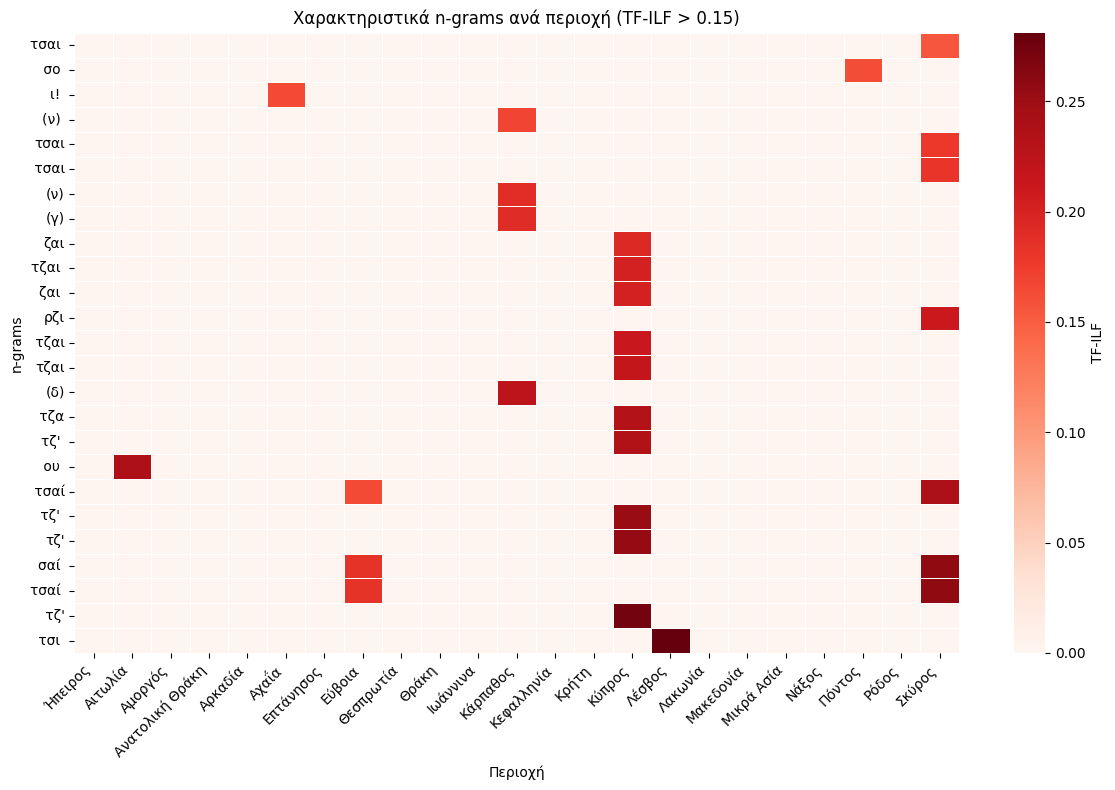

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Συγκέντρωση top τιμών
top_values = {}
for region in tfilf.index:
    top_terms = (
        tfilf.loc[region]
        .sort_values(ascending=False)
        .head(10)
    )
    top_values[region] = top_terms
top_values_df = pd.DataFrame(top_values).fillna(0)

# Threshold
threshold = 0.15
filtered_df = top_values_df.copy()
filtered_df[filtered_df < threshold] = 0
filtered_df = filtered_df[(filtered_df != 0).any(axis=1)]

# Ταξινόμηση (τα σημαντικά πιο κάτω, κοντά στις περιοχές)
filtered_df["max"] = filtered_df.max(axis=1)
filtered_df = filtered_df.sort_values("max", ascending=True)
filtered_df = filtered_df.drop(columns="max")

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(
    filtered_df,
    cmap="Reds",
    vmin=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"label": "TF-ILF"}
)
plt.title("Χαρακτηριστικά n-grams ανά περιοχή (TF-ILF > 0.15)")
plt.ylabel("n-grams")
plt.xlabel("Περιοχή")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()